In [67]:
import requests
import zipfile
import os

# Define file paths and directories for downloading and extracting the dataset
output_dir = "C:/Users/haann/Downloads"  # Change to a writable directory if needed
output_zip = os.path.join(output_dir, "flickr8k.zip")
extract_dir = os.path.join(output_dir, "flickr8k")

# Ensure the output directory exists
os.makedirs(output_dir, exist_ok=True)

# Check if the dataset is already downloaded or extracted
if not os.path.exists(output_zip) and not os.path.exists(extract_dir):
    print("Downloading Flickr8k dataset...")
    response = requests.get("https://github.com/awsaf49/flickr-dataset/releases/download/v1.0/flickr8k.zip", stream=True)
    with open(output_zip, "wb") as file:
        # Write the dataset in chunks to avoid memory issues
        for chunk in response.iter_content(chunk_size=1024):
            file.write(chunk)
    print("Download completed.")
else:
    print("Dataset already downloaded. Skipping download.")

# Extract the ZIP file only if it hasn't been extracted already
if not os.path.exists(extract_dir):
    print("Extracting dataset...")
    with zipfile.ZipFile(output_zip, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction completed.")
else:
    print("Dataset already extracted. Skipping extraction.")

# Optionally clean up by deleting the ZIP file after extraction
if os.path.exists(output_zip):
    print("Cleaning up...")
    os.remove(output_zip)

print("Downloaded Flickr8k dataset successfully.")


Dataset already downloaded. Skipping download.
Dataset already extracted. Skipping extraction.
Downloaded Flickr8k dataset successfully.


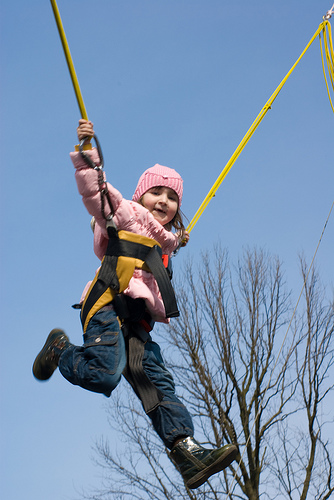

In [68]:
from PIL import Image

# Open an image file from the specified path
image = Image.open(r"C:\Users\haann\Downloads\Dl_based_image_captioning_system\flickr8k\Images\3477315700_52a4d740a5.jpg")

# Display the image inline (useful for visualization during development)
display(image)


In [69]:
from keras.applications.vgg16 import VGG16
from tensorflow.keras.models import Model
from keras.applications.imagenet_utils import preprocess_input
from keras.preprocessing.image import load_img, img_to_array
from os import listdir
from pickle import dump, load

# Function to extract features from all images in a directory using the VGG16 model
def extract_features(directory):
    # Load the VGG16 model pre-trained on ImageNet, removing the final classification layer
    model = VGG16()
    model.layers.pop()  # Remove the last layer to get feature maps
    model = Model(inputs=model.inputs, outputs=model.layers[-1].output)
    print("VGG16 model loaded.")
    
    # Dictionary to store image features with their corresponding IDs
    features = dict()

    # Process each image in the directory
    for name in listdir(directory):
        filename = os.path.join(directory, name)
        try:
            # Load and resize the image to match the VGG16 input size
            image = load_img(filename, target_size=(224, 224))
            # Convert the image to a numpy array and reshape for model input
            image = img_to_array(image)
            image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
            # Preprocess the image for VGG16 (e.g., scaling pixel values)
            image = preprocess_input(image)

            # Extract feature vector using the model
            feature = model.predict(image, verbose=0)
            # Use the image filename (without extension) as the feature key
            image_id = name.split('.')[0]
            features[image_id] = feature
            print(f"Processed {name}.")
        except Exception as e:
            # Handle and log errors for problematic files
            print(f"Error processing {name}: {e}")
    
    return features

# Directory containing the image dataset and output file path for features
dataset_directory = r"C:\Users\haann\Downloads\flickr8k\Images"  # Update to match your local dataset path
output_file = os.path.join(r"C:\Users\haann\Downloads", "features.pkl")

# Check if precomputed features already exist
if os.path.exists(output_file):
    with open(output_file, 'rb') as file:
        features = load(file)  # Load features from the pickle file
    print(f"Loaded features from {output_file}.")
else:
    # Extract features if not precomputed
    features = extract_features(dataset_directory)
    # Save the extracted features to a pickle file for reuse
    with open(output_file, 'wb') as file:
        dump(features, file)
    print(f"Features saved to {output_file}.")



Loaded features from C:\Users\haann\Downloads\features.pkl.


In [70]:
# Define the download URL and output path for the text dataset
url = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip"
output_dir = r"C:\Users\haann\Downloads\flickr8k"  # Directory to save and extract files
zip_file = os.path.join(output_dir, "Flickr8k_text.zip")

# Ensure the output directory exists; create it if it doesn't
os.makedirs(output_dir, exist_ok=True)

# Download the ZIP file containing the Flickr8k text dataset
print("Downloading Flickr8k_text.zip...")
response = requests.get(url, stream=True)
with open(zip_file, "wb") as file:
    # Write the file in chunks to avoid memory issues with large files
    for chunk in response.iter_content(chunk_size=1024):
        file.write(chunk)
print("Download completed.")

# Extract the contents of the ZIP file to the output directory
print("Extracting Flickr8k_text.zip...")
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(output_dir)
print("Extraction completed.")

# Optionally delete the ZIP file after extraction to save space
os.remove(zip_file)
print(f"Flickr8k.token.txt extracted to {output_dir}.")


Download completed.
Extracting Flickr8k_text.zip...
Extraction completed.
Flickr8k.token.txt extracted to C:\Users\haann\Downloads\flickr8k.


In [71]:
import string

# Locate the token file within the given directory structure
def find_token_file(root_directory, filename="Flickr8k.token.txt"):
    for root, _, files in os.walk(root_directory):
        if filename in files:
            return os.path.join(root, filename)
    return None

# Load the contents of a text file into memory
def load_doc(filename):
    with open(filename, 'r') as file:
        text = file.read()
    return text

# Parse image descriptions from the loaded document
def load_descriptions(doc):
    mapping = dict()
    for line in doc.split('\n'):
        tokens = line.split()
        # Skip empty or invalid lines
        if len(line) < 2:
            continue
        # Extract image ID and description
        image_id, image_desc = tokens[0], tokens[1:]
        image_id = image_id.split('.')[0]  # Remove file extension from image ID
        image_desc = ' '.join(image_desc)
        if image_id not in mapping:
            mapping[image_id] = list()
        mapping[image_id].append(image_desc)
    return mapping

# Clean image descriptions by removing noise and standardizing text
def clean_descriptions(descriptions):
    table = str.maketrans('', '', string.punctuation)  # Define a translation table to remove punctuation
    for key, desc_list in descriptions.items():
        for i in range(len(desc_list)):
            desc = desc_list[i].split()
            desc = [word.lower() for word in desc]  # Convert to lowercase
            desc = [w.translate(table) for w in desc]  # Remove punctuation
            desc = [word for word in desc if len(word) > 1]  # Remove single-character words
            desc = [word for word in desc if word.isalpha()]  # Keep only alphabetic words
            desc_list[i] = ' '.join(desc)

# Save cleaned descriptions to a text file in a consistent format
def save_descriptions(descriptions, filename):
    lines = list()
    for key, desc_list in descriptions.items():
        for desc in desc_list:
            lines.append(key + ' ' + desc)
    data = '\n'.join(lines)
    with open(filename, 'w') as file:
        file.write(data)

# Execute the processing pipeline
root_directory = r"C:\Users\haann\Downloads\flickr8k"  # Root directory of your dataset
output_file = r"C:\Users\haann\Downloads\descriptions.txt"  # Path to save the cleaned descriptions

# Locate the token file automatically
token_file = find_token_file(root_directory)

if token_file:
    print(f"Token file found: {token_file}")
    
    # Load and parse descriptions from the token file
    doc = load_doc(token_file)
    descriptions = load_descriptions(doc)
    print('Loaded descriptions:', len(descriptions))

    # Clean the descriptions to standardize the text
    clean_descriptions(descriptions)

    # Save the cleaned descriptions to a file for later use
    save_descriptions(descriptions, output_file)
    print(f"Cleaned descriptions saved to {output_file}")
else:
    print(f"Token file not found in {root_directory}. Ensure the dataset is extracted correctly.")


Token file found: C:\Users\haann\Downloads\flickr8k\Flickr8k.token.txt
Loaded descriptions: 8092
Cleaned descriptions saved to C:\Users\haann\Downloads\descriptions.txt


Loaded 8092 descriptions.


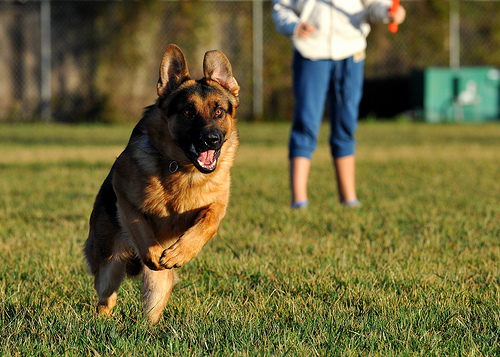

Descriptions for 3467941308_ae6989e29c:
brown dog chasing after something
brown dog is gallopsing through the grass
brown dog is running in the grass
brown dog runs fast outside on green grass
german sheperd breed dog is running in the opposite direction of person


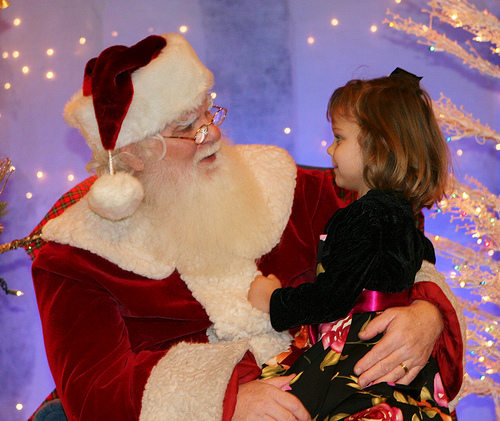

Descriptions for 3153828367_5fc2c37c07:
little girl in black dress smiles as she sits on santa lap
little girl is sitting on santa lap
man dressed as santa clause with little girl in his lap
young girl is sitting on santa lap
santa claus with young girl in black print dress in his lap


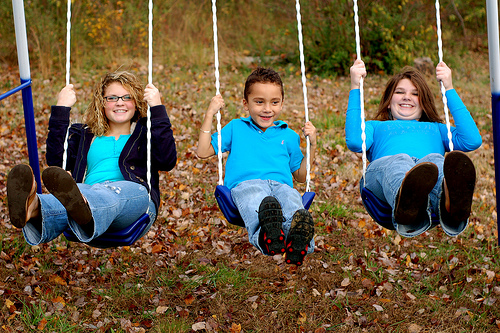

Descriptions for 3036641436_d6594fc45f:
boy sits between two girls on swing
three children in blue shirts swinging on swing set
three people on swings
three people wearing green shirts ride together on the swings
two girls swing on with boy all three are wearing blue shirts of the same shade and blue jeans


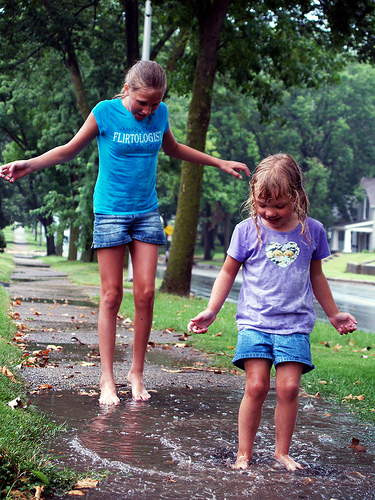

Descriptions for 2706430695_3b5667741c:
an older girl and younger girl playing barefoot in puddle
two girls are standing in shallow water without shoes
two girls in denim shorts stand in puddle of water
two girls stand in puddle on sidewalk
two girls walking on wet sidewalk


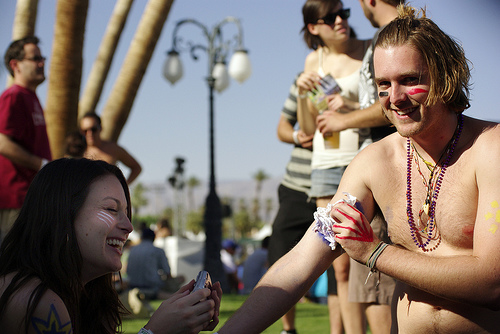

Descriptions for 3465000218_c94e54e208:
shirtless man and woman wearing at park wearing face paint and laughing
people wearing body paint outside
the man with his shirt off has paint under his eyes
the people have paint on them
two friends in park with face paint on their faces


In [77]:
from PIL import Image

# Path to the folder containing images and the file with image descriptions
dataset_directory = r"C:\Users\haann\Downloads\flickr8k\Images"
descriptions_file = r"C:\Users\haann\Downloads\descriptions.txt"

# Load descriptions from a text file into a dictionary
def load_descriptions_from_file(filename):
    descriptions = dict()
    with open(filename, 'r') as file:
        for line in file:
            tokens = line.strip().split(' ', 1)  # Split line into image ID and description
            if len(tokens) < 2:  # Skip invalid or empty lines
                continue
            image_id, description = tokens
            if image_id not in descriptions:
                descriptions[image_id] = []
            descriptions[image_id].append(description)  # Append description to the corresponding image ID
    return descriptions

# Load the descriptions into memory
descriptions = load_descriptions_from_file(descriptions_file)
print(f"Loaded {len(descriptions)} descriptions.")

# Display an image along with its associated descriptions
def display_image_and_descriptions(image_id):
    image_file = os.path.join(dataset_directory, image_id + '.jpg')  # Construct the image file path
    if os.path.exists(image_file):
        # Open and display the image
        image = Image.open(image_file)
        display(image)

        # Print descriptions associated with the image ID
        if image_id in descriptions:
            print(f"Descriptions for {image_id}:")
            print('\n'.join(descriptions[image_id]))
        else:
            print(f"No descriptions found for {image_id}.")
    else:
        print(f"Image {image_id} not found.")

# Example usage: Display images and their descriptions for specified image IDs
image_ids_to_display = ['3467941308_ae6989e29c', '3153828367_5fc2c37c07', '3036641436_d6594fc45f', '2706430695_3b5667741c', '3465000218_c94e54e208']
for image_id in image_ids_to_display:
    display_image_and_descriptions(image_id)


In [80]:
from numpy import array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout
from tensorflow.keras.layers import add
from tensorflow.keras.callbacks import ModelCheckpoint

# Import necessary libraries and modules for data processing, model building, and visualization
# - `array`: Used to create NumPy arrays for numerical computations.
# - `Tokenizer`: Helps tokenize text data and convert it into numerical format.
# - `pad_sequences`: Ensures all input sequences are of uniform length.
# - `to_categorical`: Converts labels into a one-hot encoded format.
# - `plot_model`: Visualizes the architecture of the model.
# - `Model`: Base class to define and compile a Keras model.
# - `Input`: Defines input layers for the model.
# - `Dense`: Fully connected layers for processing intermediate representations.
# - `LSTM`: Long Short-Term Memory layer for sequential data processing.
# - `Embedding`: Embedding layer for mapping tokens to dense vector representations.
# - `Dropout`: Regularization layer to prevent overfitting.
# - `add`: Used to merge layers (e.g., combining image and text inputs).
# - `ModelCheckpoint`: Saves the model during training based on performance metrics.



In [81]:
# Load the content of a text file into memory and return it as a string
def load_doc(filename):
    with open(filename, 'r') as file:
        text = file.read()  # Read the entire content of the file
    return text



In [82]:

# Load a set of unique identifiers from a file, extracted from each line
def load_set(filename):
    doc = load_doc(filename)  # Load the content of the file
    dataset = set()  # Initialize an empty set to store unique identifiers
    for line in doc.split('\n'):
        if len(line) < 1:  # Skip empty lines
            continue
        identifier = line.split('.')[0]  # Extract the identifier before the first period
        dataset.add(identifier)  # Add the identifier to the set (duplicates are automatically handled)
    return dataset


In [84]:
# Load and clean descriptions from a file, adding start and end tokens for each description
def load_clean_descriptions(filename, dataset):
    doc = load_doc(filename)  # Load the content of the description file
    descriptions = {}  # Initialize an empty dictionary to store descriptions
    for line in doc.split('\n'):
        tokens = line.split()  # Split each line into tokens
        if len(tokens) < 2:  # Skip lines with insufficient data
            continue
        image_id, image_desc = tokens[0], tokens[1:]  # Extract image ID and description
        if image_id in dataset:  # Only process descriptions for images in the dataset
            if image_id not in descriptions:
                descriptions[image_id] = []  # Initialize list if image ID not found in descriptions
            # Add 'startseq' and 'endseq' tokens to the description for sequence generation
            desc = 'startseq ' + ' '.join(image_desc) + ' endseq'
            descriptions[image_id].append(desc)  # Append the cleaned description
    return descriptions



In [85]:
# Load photo features from a file and filter them based on the provided dataset
def load_photo_features(filename, dataset):
    all_features = load(open(filename, 'rb'))  # Load the pre-saved features from the file
    features = {k: all_features[k] for k in dataset}  # Filter features to include only those in the dataset
    return features



In [86]:
# Convert the descriptions dictionary into a flat list of all descriptions
def to_lines(descriptions):
    all_desc = []  # Initialize an empty list to store all descriptions
    for key in descriptions.keys():  # Iterate over all keys in the dictionary
        [all_desc.append(d) for d in descriptions[key]]  # Append each description to the list
    return all_desc  # Return the flat list of descriptions



In [87]:
# Create a tokenizer based on the descriptions, fitting it on the entire text corpus
def create_tokenizer(descriptions):
    lines = to_lines(descriptions)  # Convert descriptions to a flat list of text lines
    tokenizer = Tokenizer()  # Initialize the Tokenizer
    tokenizer.fit_on_texts(lines)  # Fit the tokenizer on the text data to build vocabulary
    return tokenizer  # Return the fitted tokenizer



In [88]:
# Determine the maximum length of descriptions (in terms of word count)
def max_length(descriptions):
    lines = to_lines(descriptions)  # Convert descriptions to a flat list of text lines
    return max(len(d.split()) for d in lines)  # Return the maximum word count of any description



In [89]:
# Convert descriptions into input-output sequences for training the model
def create_sequences(tokenizer, max_length, desc_list, photo, vocab_size):
    X1, X2, y = [], [], []  # Initialize empty lists for input-output pairs
    for desc in desc_list:  # Iterate over each description in the list
        seq = tokenizer.texts_to_sequences([desc])[0]  # Convert description to a sequence of integers
        for i in range(1, len(seq)):  # Create input-output pairs from the sequence
            in_seq, out_seq = seq[:i], seq[i]  # Input sequence and output word (next token)
            in_seq = pad_sequences([in_seq], maxlen=max_length)[0]  # Pad input sequence to fixed length
            out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]  # Convert output word to one-hot encoding
            X1.append(photo)  # Append photo feature (same for each description)
            X2.append(in_seq)  # Append input sequence
            y.append(out_seq)  # Append output sequence (one-hot encoded word)
    return array(X1), array(X2), array(y)  # Return arrays of inputs and outputs



In [90]:
# Define and compile a multi-input model for image captioning
def define_model(vocab_size, max_length):
    # Feature extractor model (for image features)
    inputs1 = Input(shape=(1000,))  # Input for image features (size 1000)
    fe1 = Dropout(0.5)(inputs1)  # Dropout layer for regularization
    fe2 = Dense(256, activation='relu')(fe1)  # Fully connected layer with ReLU activation
    
    # Sequence model (for text input)
    inputs2 = Input(shape=(max_length,))  # Input for caption sequence (variable length)
    se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)  # Embedding layer for words
    se2 = Dropout(0.5)(se1)  # Dropout layer for regularization
    se3 = LSTM(256)(se2)  # LSTM layer to process the sequence
    
    # Decoder model (combine image and text features)
    decoder1 = add([fe2, se3])  # Merge image and sequence features
    decoder2 = Dense(256, activation='relu')(decoder1)  # Fully connected layer for fusion
    outputs = Dense(vocab_size, activation='softmax')(decoder2)  # Output layer for word prediction
    
    # Tie everything together into a single model
    model = Model(inputs=[inputs1, inputs2], outputs=outputs)
    model.compile(loss='categorical_crossentropy', optimizer='adam')  # Compile the model with appropriate loss and optimizer
    model.summary()  # Print model summary for verification
    plot_model(model, to_file='C:/Users/haann/Desktop/model.png', show_shapes=True)  # Save model architecture as an image
    return model  # Return the compiled model



In [91]:
# Data generator for batching image-caption pairs for training the model
def data_generator(descriptions, photos, tokenizer, max_length, vocab_size):
    while True:  # Infinite loop to keep generating batches
        for key, desc_list in descriptions.items():  # Iterate over each image description pair
            photo = photos[key][0]  # Get the photo feature for the image
            in_img, in_seq, out_word = create_sequences(tokenizer, max_length, desc_list, photo, vocab_size)
            
            # Convert input data and output labels to TensorFlow tensors
            in_img = tf.convert_to_tensor(in_img, dtype=tf.float32)  # Convert image features to tensor
            in_seq = tf.convert_to_tensor(in_seq, dtype=tf.int32)  # Convert input sequences to tensor
            out_word = tf.convert_to_tensor(out_word, dtype=tf.float32)  # Convert output word (one-hot encoded) to tensor
            
            # Yield a batch of data for model training
            yield (in_img, in_seq), out_word



In [92]:
# Load training data and prepare for model training
filename = r'C:\Users\haann\Downloads\flickr8k\Flickr_8k.trainImages.txt'  # Path to the training images file
train = load_set(filename)  # Load the set of training image identifiers
print(f"Dataset: {len(train)}")  # Print the number of training images

# Load and clean descriptions, and extract photo features for training
train_descriptions = load_clean_descriptions(r'C:\Users\haann\Downloads\descriptions.txt', train)  # Load and clean descriptions
train_features = load_photo_features(r'C:\Users\haann\Downloads\features.pkl', train)  # Load photo features for the training set

# Prepare tokenizer and other parameters for text processing
tokenizer = create_tokenizer(train_descriptions)  # Create a tokenizer based on training descriptions
vocab_size = len(tokenizer.word_index) + 1  # Calculate the vocabulary size (including padding)
max_len = max_length(train_descriptions)  # Determine the maximum length of the sequences


Dataset: 6000


In [93]:
# Define and compile the image captioning model
model = define_model(vocab_size, max_len)  # Create and compile the model with specified vocabulary size and maximum sequence length


Model: "functional_45"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_47      │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_46      │ (None, 1000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 34, 256)   │  1,940,224 │ input_layer_47[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 1000)      │          0 │ input_layer_46[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 34, 256)   │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_7         │ (None, 34)        │          0 │ input_layer_47[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    256,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 256)       │    525,312 │ dropout_3[0][0],  │
│                     │                   │            │ not_equal_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 256)       │          0 │ dense_3[0][0],    │
│                     │                   │            │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │     65,792 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 7579)      │  1,947,803 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,735,387 (18.06 MB)

 Trainable params: 4,735,387 (18.06 MB)

 Non-trainable params: 0 (0.00 B)

In [128]:

# Train the model using a data generator for specified epochs
epochs = 20  # Number of training epochs
steps = len(train_descriptions)  # Number of steps per epoch (based on the number of descriptions)
save_on_last_epoch = True  # Set to False to skip saving the model after training

for i in range(epochs):
    generator = data_generator(train_descriptions, train_features, tokenizer, max_len, vocab_size)  # Create data generator for training
    model.fit(generator, epochs=1, steps_per_epoch=steps, verbose=1)  # Train the model for one epoch
    
    # Save the model only after the final epoch
    if save_on_last_epoch and i == epochs - 1:
        model.save(f'model_final_epoch_{i+1}.keras')  # Save the model after the last epoch
        print(f"Model saved after final epoch {i+1}")  # Confirm the model save



6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1094s 182ms/step - loss: 5.0859
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 977s 163ms/step - loss: 3.8808
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 948s 158ms/step - loss: 3.5530
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 995s 166ms/step - loss: 3.3494
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1003s 167ms/step - loss: 3.2039
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 977s 163ms/step - loss: 3.0950
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1066s 178ms/step - loss: 3.0125
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1098s 183ms/step - loss: 2.9391
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1117s 186ms/step - loss: 2.8864
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1124s 187ms/step - loss: 2.8322
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1126s 188ms/step - loss: 2.7926
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1135s 189ms/step - loss: 2.7561
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1162s 194ms/step - loss: 2.7308
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1165s 194ms/step - loss: 2.7038
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1280s 213ms/step - loss: 2.6838
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 1200s 200ms/step - loss: 2.6

In [94]:
# Print the current working directory
print("Current working directory:", os.getcwd())  # Display the path of the current working directory




Current working directory: c:\Users\haann\Downloads\Dl_based_image_captioning_system


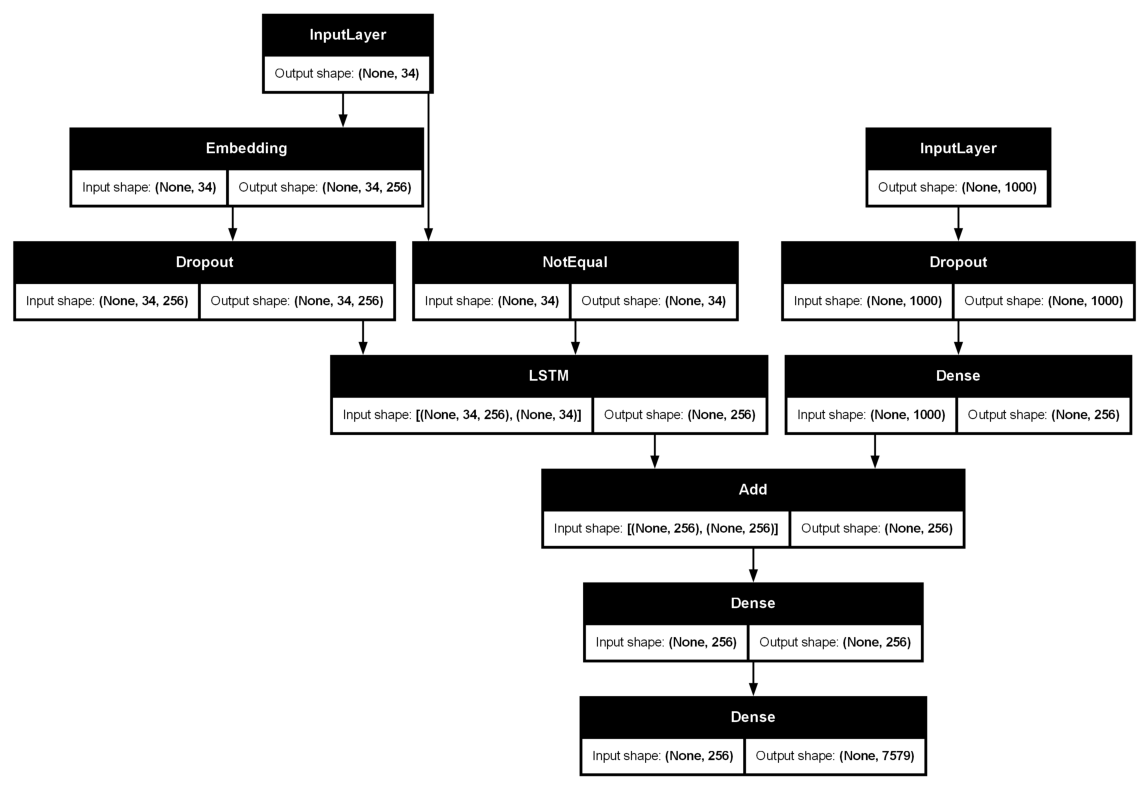

In [95]:
import matplotlib.pyplot as plt

# Display the model architecture image
image_path = r"C:\Users\haann\Desktop\model.png"  # Path to the saved model architecture image
image = Image.open(image_path)  # Open the image file

# Adjust figure size for better visualization
plt.figure(figsize=(25, 10))  # Set the figure size (width, height) for a larger display
plt.imshow(image)  # Display the image
plt.axis('off')  # Hide axes for cleaner presentation
plt.show()  # Show the image


In [96]:
# Print the shape of the feature vector for a specific image
print(train_features['2513260012_03d33305cf'].shape)  # Display the shape of the feature vector for the image with the given ID


(1, 1000)


In [97]:
# Save the tokenizer to a file using pickle
tokenizer_path = r"C:\Users\haann\Desktop\tokenizer.pkl"  # Define the path to save the tokenizer

# Save the tokenizer object to the specified file
with open(tokenizer_path, 'wb') as file:
    pickle.dump(tokenizer, file)  # Serialize and save the tokenizer

print(f"Tokenizer saved successfully to {tokenizer_path}")  # Confirm that the tokenizer has been saved


Tokenizer saved successfully to C:\Users\haann\Desktop\tokenizer.pkl


In [98]:
def word_for_id(integer, tokenizer):
    # Retrieve the word corresponding to the given integer from the tokenizer's word index
    for word, index in tokenizer.word_index.items():
        if index == integer:
            return word
    return None

def generate_desc(model, tokenizer, photo, max_length):
    """
    Generate a description for an image using the trained model and tokenizer.

    Parameters:
    - model: The trained model for generating captions.
    - tokenizer: The tokenizer used for converting words to sequences and vice versa.
    - photo: The feature vector of the processed image.
    - max_length: The maximum length allowed for the generated description.

    Returns:
    - in_text: The generated description as a string.
    """
    in_text = 'startseq'  # Initialize the description with the start token
    for i in range(max_length):
        # Convert the current description to a sequence of integers
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        # Pad the sequence to ensure it matches the required length
        sequence = pad_sequences([sequence], maxlen=max_length)
        # Predict the next word based on the image features and current sequence
        yhat = model.predict([photo, sequence], verbose=0)
        # Get the word with the highest predicted probability
        yhat = np.argmax(yhat)
        # Find the word corresponding to the predicted index
        word = word_for_id(yhat, tokenizer)
        # If no word is found, stop the generation
        if word is None:
            break
        # Append the word to the current description
        in_text += ' ' + word
        # Stop generating if the end token is predicted
        if word == 'endseq':
            break
    return in_text


In [99]:
from pickle import load

# Load the previously saved tokenizer from the specified file
tokenizer_path = r"C:\Users\haann\Desktop\tokenizer.pkl"
with open(tokenizer_path, 'rb') as file:
    tokenizer = load(file)  # Load the tokenizer object





In [102]:
from tensorflow.keras.models import load_model

max_length = 32  # Define the maximum length for generated descriptions
# Load the trained model from the specified file
model = load_model(r"C:\Users\haann\Downloads\model_final_epoch_20.keras")

# Display the model architecture summary
model.summary()  # Prints the details of the model's layers and parameters


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_6       │ (None, 1000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 34, 256)   │  1,940,224 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 1000)      │          0 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 34, 256)   │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_9         │ (None, 34)        │          0 │ input_layer_7[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 256)       │    256,256 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 256)       │    525,312 │ dropout_7[0][0],  │
│                     │                   │            │ not_equal_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 256)       │          0 │ dense_10[0][0],   │
│                     │                   │            │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 256)       │     65,792 │ add_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 7579)      │  1,947,803 │ dense_11[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,206,163 (54.19 MB)

 Trainable params: 4,735,387 (18.06 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,470,776 (36.13 MB)

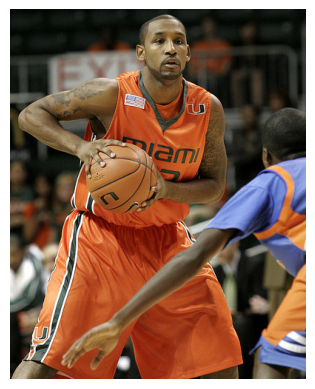

Generated Caption: the man is holding the basketball from the ball


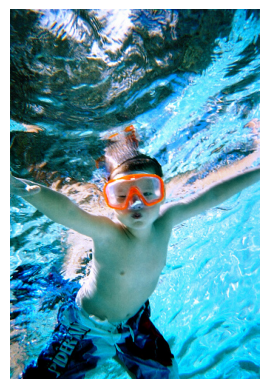

Generated Caption: boy in red swim trunks is playing in pool


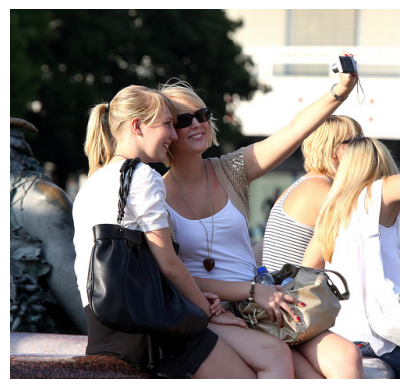

Generated Caption: man in black shirt and sunglasses is sitting on bench


In [119]:
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=UserWarning)  # Suppress warnings for a cleaner output

# Define the function to process a single image and extract features using VGG16
def extract_feature_single_image(filename):
    """
    Extracts features from a single image using the VGG16 model.

    Parameters:
    - filename (str): Path to the image file.

    Returns:
    - feature (ndarray): Extracted feature vector from the image.
    """
    # Load the pre-trained VGG16 model without the last layer
    model = VGG16()
    model.layers.pop()  # Remove the classification layer to get feature maps
    model = Model(inputs=model.inputs, outputs=model.layers[-1].output)  # Create new model

    # Load and preprocess the image
    image = load_img(filename, target_size=(224, 224))  # Resize image to match VGG16 input size
    image = img_to_array(image)  # Convert image to array
    image = np.expand_dims(image, axis=0)  # Add batch dimension for prediction

    image = preprocess_input(image)  # Preprocess image for VGG16

    # Extract feature from the image
    feature = model.predict(image, verbose=0)
    return feature

# Define the function to generate and display a caption for an image
def generate_and_display_caption(image_path):
    """
    Generates a caption for a single image and displays it alongside the image.

    Parameters:
    - image_path (str): Path to the image file for which the caption will be generated.
    """
    # Extract features from the image
    photo = extract_feature_single_image(image_path)

    # Generate a caption using the trained model
    description = generate_desc(model, tokenizer, photo, max_len)  # Generate description
    description = description[len("startseq "):-len(" endseq")]  # Clean up the description

    # Display the image
    image = Image.open(image_path)
    plt.imshow(image)
    plt.axis('off')  # Hide axes for a better visualization
    plt.show()

    # Print the generated caption
    print(f"Generated Caption: {description}")

# Example usage: Generate and display captions for multiple images
image_paths = [
    r"C:\Users\haann\Downloads\Dl_based_image_captioning_system\flickr8k\Images\2993167197_e5d0a73530.jpg",
    r"C:\Users\haann\Downloads\Dl_based_image_captioning_system\flickr8k\Images\2822891602_ff61df2ece.jpg",
    r"C:\Users\haann\Downloads\Dl_based_image_captioning_system\flickr8k\Images\2736902411_a0010f89ae.jpg"
]

# Loop through the image paths and generate captions
for image_path in image_paths:
    generate_and_display_caption(image_path)


